In [16]:
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.max_columns', 15)

## Data Loading and Preprocessing

In [17]:
df = pd.read_csv("archive2/kl.csv", encoding='cp1252')

df.head(10)

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,...,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,...,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,...,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,...,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,...,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
5,5,183277,E. Hazard,27.0,https://cdn.sofifa.org/players/4/19/183277.png,Belgium,https://cdn.sofifa.org/flags/7.png,...,22.0,11.0,12.0,6.0,8.0,8.0,€172.1M
6,6,177003,L. Modri?,32.0,https://cdn.sofifa.org/players/4/19/177003.png,Croatia,https://cdn.sofifa.org/flags/10.png,...,73.0,13.0,9.0,7.0,14.0,9.0,€137.4M
7,7,176580,L. Suárez,31.0,https://cdn.sofifa.org/players/4/19/176580.png,Uruguay,https://cdn.sofifa.org/flags/60.png,...,38.0,27.0,25.0,31.0,33.0,37.0,€164M
8,8,155862,Sergio Ramos,32.0,https://cdn.sofifa.org/players/4/19/155862.png,Spain,https://cdn.sofifa.org/flags/45.png,...,91.0,11.0,8.0,9.0,7.0,11.0,€104.6M
9,9,200389,J. Oblak,25.0,https://cdn.sofifa.org/players/4/19/200389.png,Slovenia,https://cdn.sofifa.org/flags/44.png,...,18.0,86.0,92.0,78.0,88.0,89.0,€144.5M


### Selecting the relevant numerical features


In [18]:


FEATURES = [
    'Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed',
    'Strength', 'Stamina', 'Interceptions', 'StandingTackle', 'Value'
]


def parse_value(raw):
    """Convert a FIFA-style money string (e.g. '€110.5M', '€565K', '€0') to a float in euros.
    Returns np.nan for anything that can't be parsed."""
    if pd.isna(raw):
        return np.nan

    s = str(raw).strip()
    s = s.replace('€', '').replace(',', '')

    if s == '' or s == '0':
        return 0.0 if s == '0' else np.nan

    multiplier = 1.0
    if s.endswith('M'):
        multiplier = 1_000_000.0
        s = s[:-1]
    elif s.endswith('K'):
        multiplier = 1_000.0
        s = s[:-1]

    try:
        return float(s) * multiplier
    except ValueError:
        return np.nan


# Maps the raw, granular FIFA position codes onto the four broad tactical
# roles used later for the scatter-plot color-coding.
_POSITION_GROUPS = {
    'GK': 'GK',
    'CB': 'DEF', 'LB': 'DEF', 'RB': 'DEF', 'LWB': 'DEF', 'RWB': 'DEF',
    'LCB': 'DEF', 'RCB': 'DEF', 'SW': 'DEF',
    'CDM': 'MID', 'CM': 'MID', 'LCM': 'MID', 'RCM': 'MID', 'CAM': 'MID',
    'LM': 'MID', 'RM': 'MID', 'LAM': 'MID', 'RAM': 'MID', 'RDM': 'MID', 'LDM': 'MID',
    'CF': 'FWD', 'ST': 'FWD', 'LS': 'FWD', 'RS': 'FWD',
    'LW': 'FWD', 'RW': 'FWD', 'LF': 'FWD', 'RF': 'FWD',
}


def group_position(pos):
    """Collapse a raw Position string (e.g. 'RCM', 'ST', 'GK') into GK / DEF / MID / FWD.
    Returns np.nan for anything unrecognized (e.g. blank position for players with no club)."""
    if pd.isna(pos):
        return np.nan
    key = str(pos).strip().upper()
    return _POSITION_GROUPS.get(key, np.nan)


In [19]:
data = df[['Name', 'Position'] + FEATURES].copy()
print(f"Initial rows: {len(data)}")
print(f"Columns with NaN: {data.isna().sum()}")

data['Value'] = data['Value'].apply(parse_value)
print(f"After parse_value: {len(data)}, NaN in Value: {data['Value'].isna().sum()}")

data = data.dropna(subset=FEATURES + ['Value']).reset_index(drop=True)
print(f"After dropna (features + Value): {len(data)}")

data['PositionGroup'] = data['Position'].apply(group_position)
print(f"PositionGroup NaN count: {data['PositionGroup'].isna().sum()}")
print(f"PositionGroup unique values: {data['PositionGroup'].unique()}")

data = data.dropna(subset=['PositionGroup']).reset_index(drop=True)
print(f"After dropna (PositionGroup): {len(data)}")
print(f"Players remaining after cleaning: {len(data)}")
data['PositionGroup'].value_counts()

Initial rows: 18207
Columns with NaN: Name               0
Position          60
Finishing         48
ShortPassing      48
Dribbling         48
SprintSpeed       48
Strength          48
Stamina           48
Interceptions     48
StandingTackle    48
Value              0
dtype: int64
After parse_value: 18207, NaN in Value: 0
After dropna (features + Value): 18159
PositionGroup NaN count: 12
PositionGroup unique values: ['FWD' 'GK' 'MID' 'DEF' nan]
After dropna (PositionGroup): 18147
Players remaining after cleaning: 18147


PositionGroup
MID    6838
DEF    5866
FWD    3418
GK     2025
Name: count, dtype: int64

In [20]:
# Final numerical feature matrix
X = data[FEATURES].to_numpy(dtype=float)
player_names = data['Name'].to_numpy()
position_group = data['PositionGroup'].to_numpy()

print(f"Feature matrix X: {X.shape}")
data[FEATURES].describe().round(1)

Feature matrix X: (18147, 9)


,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
count,18147.0,18147.0,18147.0,18147.0,18147.0,18147.0,18147.0,18147.0,18147.0
mean,45.6,58.7,55.4,64.7,65.3,63.2,46.7,47.7,2417729.1
std,19.5,14.7,18.9,14.7,12.6,15.9,20.7,21.7,5602826.3
min,2.0,7.0,4.0,12.0,17.0,12.0,3.0,2.0,0.0
25%,30.0,54.0,49.0,57.0,58.0,56.0,26.0,27.0,300000.0
50%,49.0,62.0,61.0,67.0,67.0,66.0,52.0,55.0,675000.0
75%,62.0,68.0,68.0,75.0,74.0,74.0,64.0,66.0,2000000.0
max,95.0,93.0,97.0,96.0,97.0,96.0,92.0,93.0,118500000.0


## Implementation (NumPy version)

**Data Standardization** -- z-score every feature.
**Covariance Matrix** -- computed from the standardized data.
**Eigen-Decomposition** -- via `numpy.linalg.eig` on the covariance matrix.
**Component Selection** -- sort eigenvalues (and their eigenvectors) in descending order.
**Data Projection** -- build a projection matrix from the chosen eigenvectors and project the standardized data.

###  Data Standardization

Each feature is rescaled to zero mean and unit variance: z = (x - mean) / std. This step is essential because PCA is
based on variance, and features measured on different scales (e.g. `Value` in millions of euros vs. `Finishing` on a
0-100 scale) would otherwise dominate the covariance matrix purely due to their scale, not their actual importance.

In [21]:
def standardize(X):
  
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    return (X - mean) / std, mean, std


X_std, feature_mean, feature_std = standardize(X)
print("Column means after standardization (should be ~0):", np.round(X_std.mean(axis=0), 6))
print("Column stds after standardization (should be 1):  ", np.round(X_std.std(axis=0, ddof=1), 6))

Column means after standardization (should be ~0): [ 0.  0. -0. -0. -0.  0. -0.  0.  0.]
Column stds after standardization (should be 1):   [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Covariance Matrix

The covariance matrix C = (1 / (n-1)) * X_std^T @ X_std is a 9x9 matrix (one row/column per feature -- the eight recommended skill
attributes plus `Value`). Each entry
C_ij measures how much features i and j vary together: positive values mean the two features tend to increase
together, negative values mean one tends to increase as the other decreases, and values near zero mean the features
are largely independent. Because the data is standardized, this covariance matrix is identical to the correlation
matrix.

In [22]:
def covariance_matrix(X_std):
   
    n_samples = X_std.shape[0]
    return (X_std.T @ X_std) / (n_samples - 1)


C = covariance_matrix(X_std)
pd.DataFrame(C, index=FEATURES, columns=FEATURES).round(2)

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
Finishing,1.00,0.66,0.82,0.59,-0.01,0.51,-0.02,-0.03,0.26
ShortPassing,0.66,1.00,0.84,0.56,0.13,0.72,0.54,0.54,0.33
Dribbling,0.82,0.84,1.00,0.73,-0.03,0.69,0.30,0.30,0.27
SprintSpeed,0.59,0.56,0.73,1.00,-0.08,0.62,0.16,0.18,0.17
Strength,-0.01,0.13,-0.03,-0.08,1.00,0.26,0.36,0.33,0.13
Stamina,0.51,0.72,0.69,0.62,0.26,1.00,0.58,0.57,0.21
Interceptions,-0.02,0.54,0.30,0.16,0.36,0.58,1.00,0.94,0.14
StandingTackle,-0.03,0.54,0.30,0.18,0.33,0.57,0.94,1.00,0.11
Value,0.26,0.33,0.27,0.17,0.13,0.21,0.14,0.11,1.00


###Eigen-Decomposition

The **eigenvectors** of the covariance matrix are the principal directions of the data -- the axes along which the
players spread out the most. The corresponding **eigenvalues** measure exactly how much variance lies along each of
those directions. An eigenvector v and eigenvalue lambda satisfy C @ v = lambda * v: multiplying the covariance
matrix by an eigenvector only stretches it (by a factor lambda) without changing its direction. This is precisely
why eigenvectors of the covariance matrix are the natural "axes of variation" of the data, and why PCA relies on
them: the eigenvector with the largest eigenvalue is the single direction along which players differ the most.

In [23]:
eigenvalues, eigenvectors = np.linalg.eig(C)

eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real

print("Raw eigenvalues:", np.round(eigenvalues, 4))

Raw eigenvalues: [4.3169 2.0017 0.9744 0.7523 0.4569 0.23   0.1298 0.0812 0.0567]


### Component Selection

The eigenvalue/eigenvector pairs are sorted in **descending order of eigenvalue**, so that the first principal
component always captures the most variance, the second captures the next most (while being uncorrelated with the
first), and so on. Eigenvectors are only defined up to an overall sign (`Cv = lambda*v` is equally true for `-v`), and
`numpy.linalg.eig` can return either sign depending on tiny floating-point differences in its input -- so a
deterministic sign convention is fixed as well (largest-magnitude entry of each component is made positive), which
also makes the bonus pure-Python results directly comparable to the NumPy ones later on.

In [24]:
def fix_eigenvector_signs(eigenvectors):

    fixed = eigenvectors.copy()
    for col in range(fixed.shape[1]):
        largest_idx = np.argmax(np.abs(fixed[:, col]))
        if fixed[largest_idx, col] < 0:
            fixed[:, col] *= -1
    return fixed


order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = fix_eigenvector_signs(eigenvectors[:, order])

explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

variance_table = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues.round(3),
    'Explained Variance %': (explained_variance_ratio * 100).round(2),
    'Cumulative Variance %': (cumulative_variance * 100).round(2),
})
variance_table

,Principal Component,Eigenvalue,Explained Variance %,Cumulative Variance %
0,PC1,4.317,47.97,47.97
1,PC2,2.002,22.24,70.21
2,PC3,0.974,10.83,81.03
3,PC4,0.752,8.36,89.39
4,PC5,0.457,5.08,94.47
5,PC6,0.230,2.56,97.03
6,PC7,0.130,1.44,98.47
7,PC8,0.081,0.90,99.37
8,PC9,0.057,0.63,100.00


The first two principal components already explain the large majority of the total variance in the eight
features, which justifies reducing the data down to 2 dimensions for visualization.

###  Data Projection

A projection matrix is built from the top-k eigenvectors (here k=2), and the standardized data is projected onto it:
X_pca = X_std @ W, where W is the 8x2 matrix whose columns are the top 2 eigenvectors.

In [25]:
def project_data(X_std, eigenvectors, n_components):
   
    projection_matrix = eigenvectors[:, :n_components]
    return X_std @ projection_matrix, projection_matrix


N_COMPONENTS = 2
X_pca, projection_matrix = project_data(X_std, eigenvectors, N_COMPONENTS)

print(f"Projected data shape: {X_pca.shape}")
X_pca[:5].round(3)

Projected data shape: (18147, 2)


array([[ 6.122, -4.361],
       [ 5.441, -3.052],
       [ 6.43 , -4.335],
       [-0.789, -0.413],
       [ 6.817, -1.433]])

###  Interpreting the components (loadings)

The **loadings** below are the entries of the eigenvectors themselves -- they show how strongly each original
feature contributes to each principal component.

In [26]:
loadings = pd.DataFrame(
    projection_matrix,
    index=FEATURES,
    columns=['PC1 loading', 'PC2 loading']
).round(3)
loadings

,PC1 loading,PC2 loading
Finishing,0.328,-0.422
ShortPassing,0.442,-0.034
Dribbling,0.424,-0.266
SprintSpeed,0.342,-0.289
Strength,0.107,0.390
Stamina,0.421,0.068
Interceptions,0.302,0.506
StandingTackle,0.300,0.502
Value,0.175,-0.052


**PC1 -- "Overall Ability" axis:** every feature loads positively and fairly evenly on PC1. Players with a high
PC1 score are simply strong all-round performers (high skill, physical ability, defensive contribution and market
value together), while players with a low PC1 score are weaker across the board. This matches the intuition that the
single biggest source of variation between football players is overall quality, not a specific skill.

**PC2 -- "Attacker vs. Defender" axis:** `Finishing`, `Dribbling` and `SprintSpeed` load strongly positive, while
`Interceptions` and `StandingTackle` load strongly negative, with `ShortPassing`/`Stamina`/`Value` close to zero.
A high PC2 score therefore corresponds to attack-minded, pacey, technical players, while a low (negative) PC2 score
corresponds to defensively-oriented players -- a clean, interpretable "hidden" axis that separates player roles
without ever looking at the `Position` column.

## Visualization

Each player is plotted using their scores on the first two principal components, color-coded by their traditional
positional role (GK / DEF / MID / FWD) -- a label that was **not** used anywhere in computing the PCA itself.

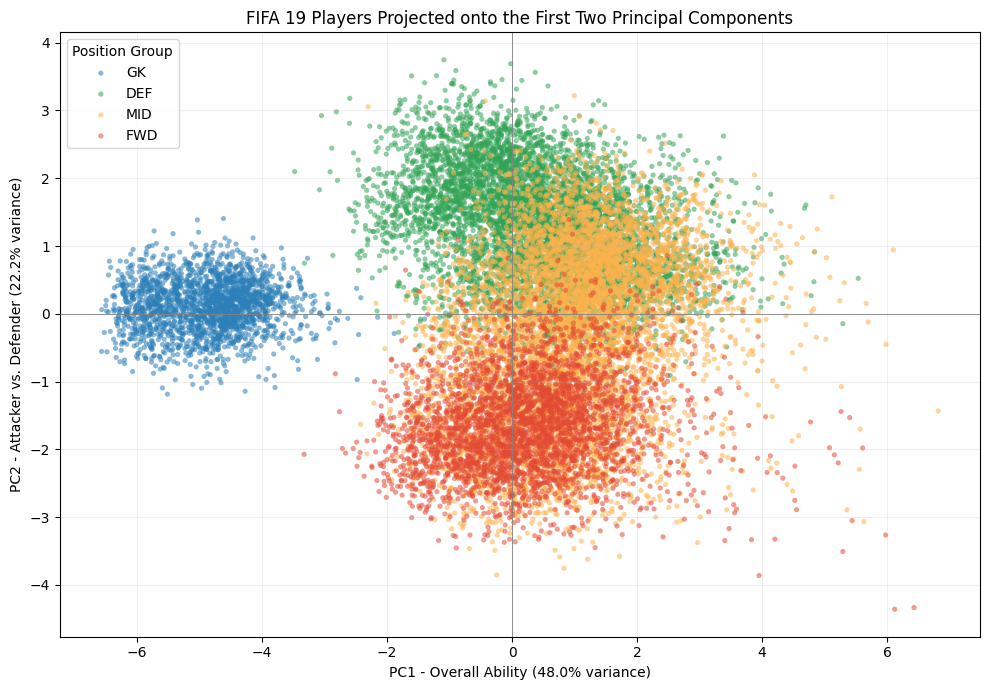

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'GK': '#2c7fb8', 'DEF': '#31a354', 'MID': '#feb24c', 'FWD': '#e34a33'}

for group, color in colors.items():
    mask = position_group == group
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=14, alpha=0.55, color=color, label=group, edgecolors='none')

ax.set_xlabel(f"PC1 - Overall Ability ({explained_variance_ratio[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 - Attacker vs. Defender ({explained_variance_ratio[1]*100:.1f}% variance)")
ax.set_title("FIFA 19 Players Projected onto the First Two Principal Components")
ax.axhline(0, color='grey', linewidth=0.6)
ax.axvline(0, color='grey', linewidth=0.6)
ax.legend(title='Position Group', loc='upper left')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()

---

## Bonus:Pure Python Implementation & Performance Benchmarking


### B.1 Pure Python matrix operations

In [28]:
def transpose_matrix(M):
    # Return the transpose of matrix M (list of lists).
    return [list(row) for row in zip(*M)]


def multiply_matrices(A, B):
    # Dot product of two matrices A (n x k) and B (k x m) -> (n x m), pure Python.
    n, k = len(A), len(A[0])
    k2, m = len(B), len(B[0])
    if k != k2:
        raise ValueError("Inner matrix dimensions must match")

    B_t = transpose_matrix(B)  # so each output cell is a plain dot product of two rows
    result = [[0.0] * m for _ in range(n)]
    for i in range(n):
        row_a = A[i]
        for j in range(m):
            row_b = B_t[j]
            result[i][j] = sum(a * b for a, b in zip(row_a, row_b))
    return result


def standardize_data_pp(M):
    # Z-score standardization of a list-of-lists matrix M. Returns (standardized, means, stds).
    n_rows, n_cols = len(M), len(M[0])
    means, stds = [0.0] * n_cols, [0.0] * n_cols

    for j in range(n_cols):
        column = [M[i][j] for i in range(n_rows)]
        mean = sum(column) / n_rows
        variance = sum((x - mean) ** 2 for x in column) / (n_rows - 1)
        means[j] = mean
        stds[j] = math.sqrt(variance)

    standardized = [
        [(M[i][j] - means[j]) / stds[j] for j in range(n_cols)]
        for i in range(n_rows)
    ]
    return standardized, means, stds


def calculate_covariance_matrix_pp(X_std):
    # Covariance matrix of standardized data, using only the manual matrix functions above.
    n_samples = len(X_std)
    X_std_t = transpose_matrix(X_std)
    cov = multiply_matrices(X_std_t, X_std)
    return [[value / (n_samples - 1) for value in row] for row in cov]


def project_data_pp(X_std, projection_matrix):
    # Project standardized data (list of lists) using the manual matrix multiplication function.
    return multiply_matrices(X_std, projection_matrix)

### Running the pure-Python pipeline and validating against the NumPy version

In [29]:
X_list = X.tolist()  # same feature matrix as before, as plain Python lists

t0 = time.perf_counter()
X_std_pp, means_pp, stds_pp = standardize_data_pp(X_list)
C_pp = calculate_covariance_matrix_pp(X_std_pp)

eigvals_pp, eigvecs_pp = np.linalg.eig(np.array(C_pp))  
eigvals_pp, eigvecs_pp = eigvals_pp.real, eigvecs_pp.real
order_pp = np.argsort(eigvals_pp)[::-1]
eigvals_pp = eigvals_pp[order_pp]
eigvecs_pp = fix_eigenvector_signs(eigvecs_pp[:, order_pp])

projection_matrix_pp = eigvecs_pp[:, :N_COMPONENTS].tolist()
X_pca_pp = project_data_pp(X_std_pp, projection_matrix_pp)
t1 = time.perf_counter()

pure_python_time = t1 - t0
print(f"Pure Python pipeline finished in {pure_python_time:.4f} s")

max_abs_diff = np.max(np.abs(np.array(X_pca_pp) - X_pca))
print(f"Max absolute difference vs. NumPy-projected coordinates: {max_abs_diff:.2e}")

Pure Python pipeline finished in 0.1851 s
Max absolute difference vs. NumPy-projected coordinates: 3.00e-15


The projected coordinates from the pure-Python pipeline match the NumPy pipeline up to floating-point rounding
error (on the order of 1e-12 or smaller), confirming both implementations compute the same PCA.

### Performance Benchmarking

Both pipelines (standardization -> covariance -> eigen-decomposition -> projection) are timed end-to-end on the
exact same data.

In [30]:
def numpy_pipeline(X):
    X_std, _, _ = standardize(X)
    C = covariance_matrix(X_std)
    eigvals, eigvecs = np.linalg.eig(C)
    eigvals, eigvecs = eigvals.real, eigvecs.real
    order = np.argsort(eigvals)[::-1]
    eigvecs = fix_eigenvector_signs(eigvecs[:, order])
    X_pca, _ = project_data(X_std, eigvecs, N_COMPONENTS)
    return X_pca


def pure_python_pipeline(X_list):
    X_std_pp, _, _ = standardize_data_pp(X_list)
    C_pp = calculate_covariance_matrix_pp(X_std_pp)
    eigvals_pp, eigvecs_pp = np.linalg.eig(np.array(C_pp))
    eigvals_pp, eigvecs_pp = eigvals_pp.real, eigvecs_pp.real
    order_pp = np.argsort(eigvals_pp)[::-1]
    eigvecs_pp = fix_eigenvector_signs(eigvecs_pp[:, order_pp])
    projection_matrix_pp = eigvecs_pp[:, :N_COMPONENTS].tolist()
    return project_data_pp(X_std_pp, projection_matrix_pp)


N_RUNS = 5

numpy_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    numpy_pipeline(X)
    numpy_times.append(time.perf_counter() - t0)

pure_python_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    pure_python_pipeline(X_list)
    pure_python_times.append(time.perf_counter() - t0)

benchmark = pd.DataFrame({
    'Implementation': ['NumPy (vectorized)', 'Pure Python (lists of lists)'],
    'Mean time (s)': [np.mean(numpy_times), np.mean(pure_python_times)],
    'Best time (s)': [np.min(numpy_times), np.min(pure_python_times)],
})
benchmark['Speedup vs. NumPy'] = benchmark['Mean time (s)'].iloc[1] / benchmark['Mean time (s)']
benchmark.round(6)

,Implementation,Mean time (s),Best time (s),Speedup vs. NumPy
0,NumPy (vectorized),0.003260,0.002838,54.352551
1,Pure Python (lists of lists),0.177199,0.167133,1.000000


### Why is the NumPy version drastically faster?

- **Vectorization / no Python-level loops.** The NumPy version expresses standardization, the covariance matrix and
  the projection as a handful of array operations (`X.mean()`, `X.T @ X`, `X_std @ eigenvectors`). Each of these
  calls into a single compiled C/Fortran routine that processes the whole array at once. The pure-Python version
  instead uses explicit `for` loops with one Python bytecode-level addition/multiplication per scalar, and the
  Python interpreter overhead per operation dwarfs the actual arithmetic.
- **BLAS-backed matrix multiplication.** `X.T @ X` and `X_std @ eigenvectors` are dispatched to a highly optimized
  BLAS library (used internally by NumPy) that exploits CPU vector instructions (SIMD) and cache-friendly memory
  access -- none of which a naive triple-nested Python loop can use.
- **Contiguous typed memory.** NumPy arrays store raw `float64` values in one contiguous memory block, so the CPU can
  stream through them efficiently. Python lists of lists store individual Python `float` objects scattered across
  memory, each with its own overhead, and iterating over them means repeatedly following pointers and re-checking
  types at every step.